In [1]:
# Setup and imports
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

# Repo-Root vor dem site-packages-Paket in den sys.path einfügen, damit
# Änderungen am lokalen mdxplain-Code ohne Neuinstallation wirksam werden
PROJECT_ROOT = Path.cwd().resolve().parents[1]  # spec/tests -> repo root
if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

from mdxplain import PipelineManager
from spec import SpecManager

📦 Creating Zarr cache: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/spec/tests/cache/cache_8e39964c2fc9491e9a0ab1767ce21dcb_20260827_145502/2RJY_protein_simulation_run1_3dac6f5d.dask.zarr
  🔍 Analyzing trajectory dimensions...
  📐 Trajectory: 10001 frames × 1027 atoms
  💾 Writing trajectory data...
  ✅ Cache created: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/spec/tests/cache/cache_8e39964c2fc9491e9a0ab1767ce21dcb_20260827_145502/2RJY_protein_simulation_run1_3dac6f5d.dask.zarr
  📊 Size: 89.0 MB

Loaded 1 systems with 1 total trajectories:
  2RJY: 1 trajectories
Loading 117.5 MB coordinate data...
Generated 1953 residue pairs for 64 residues
Created feature selector: 'contacts_only'
Added to selector 'contacts_only': contacts -> 'all' (use_reduced=False, common_denominator=True, traj_selection=all, require_all_partners=False)
Applied feature selector 'contacts_only' with reference trajectory 0 successfully
Starting eigendecomposition for 4 components...
Eigendeco

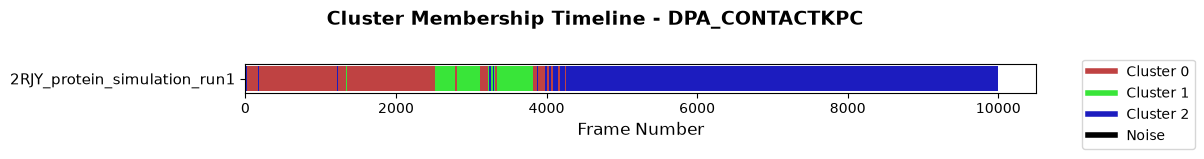

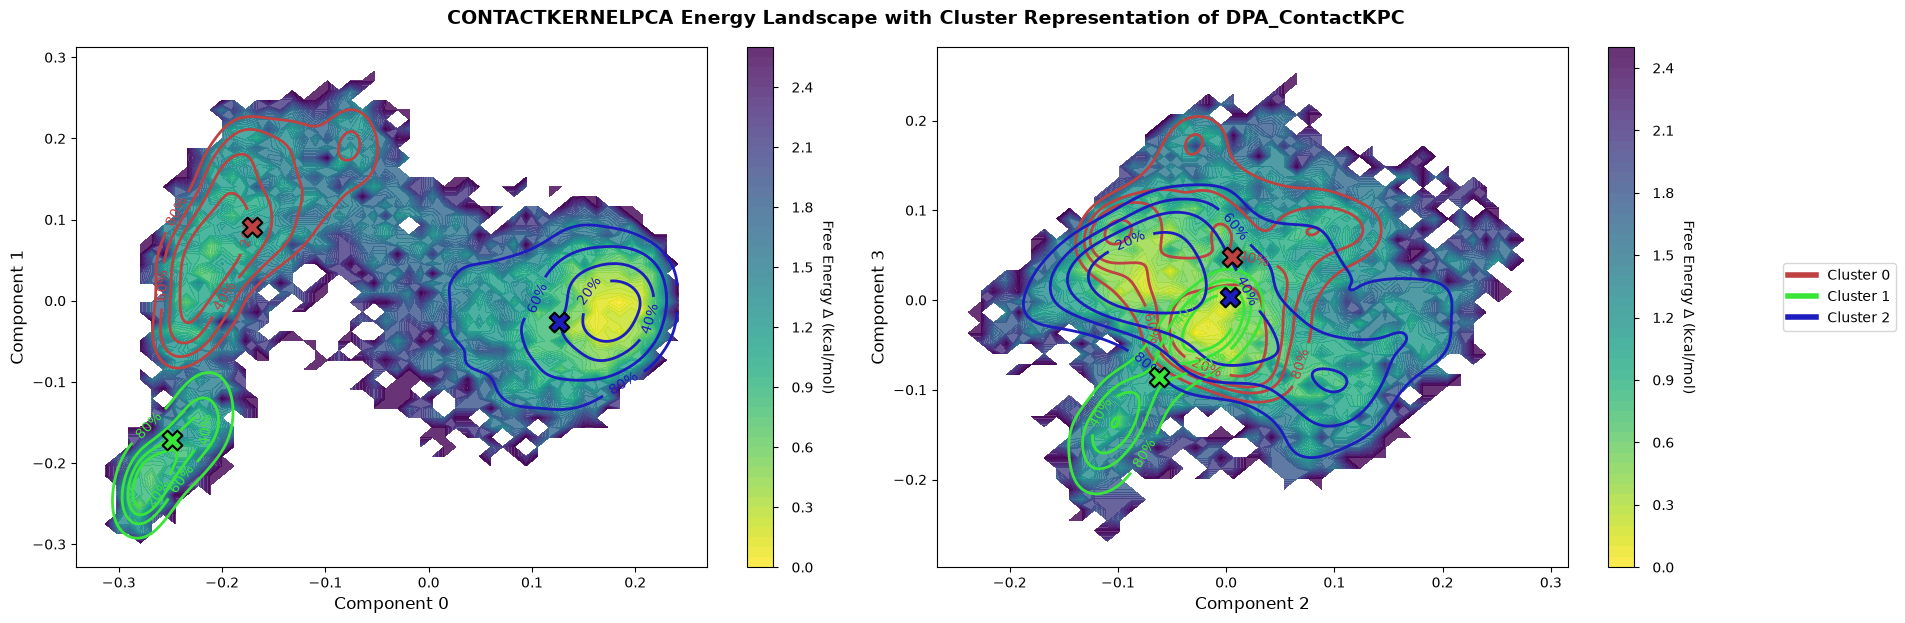

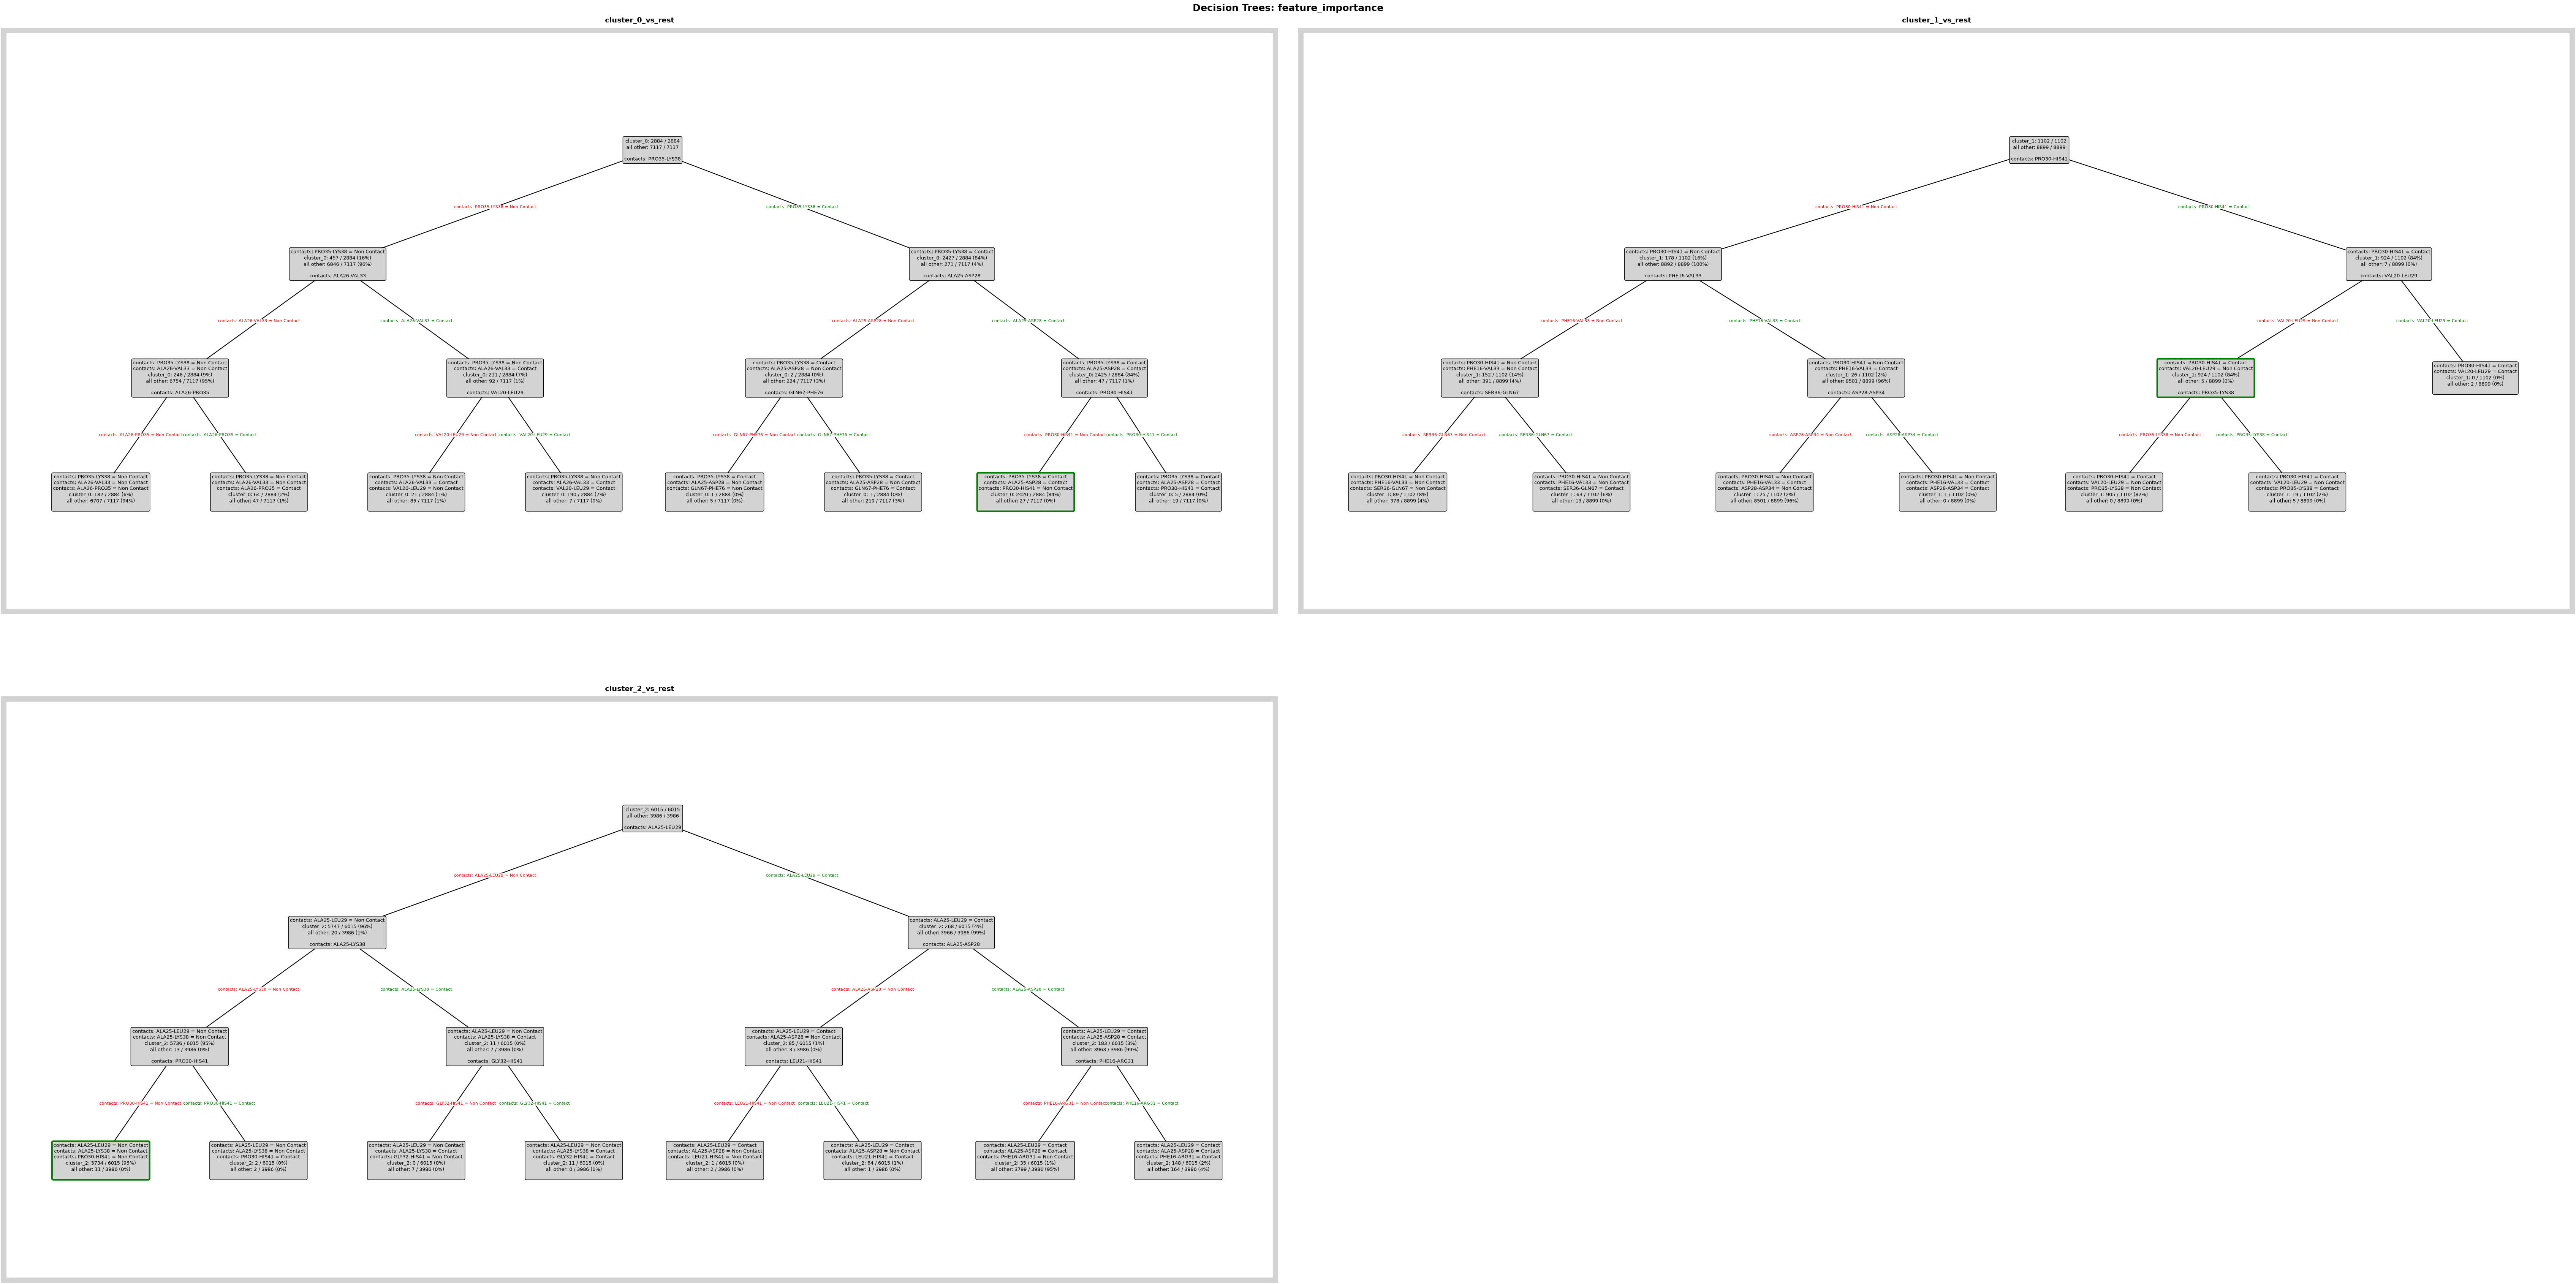

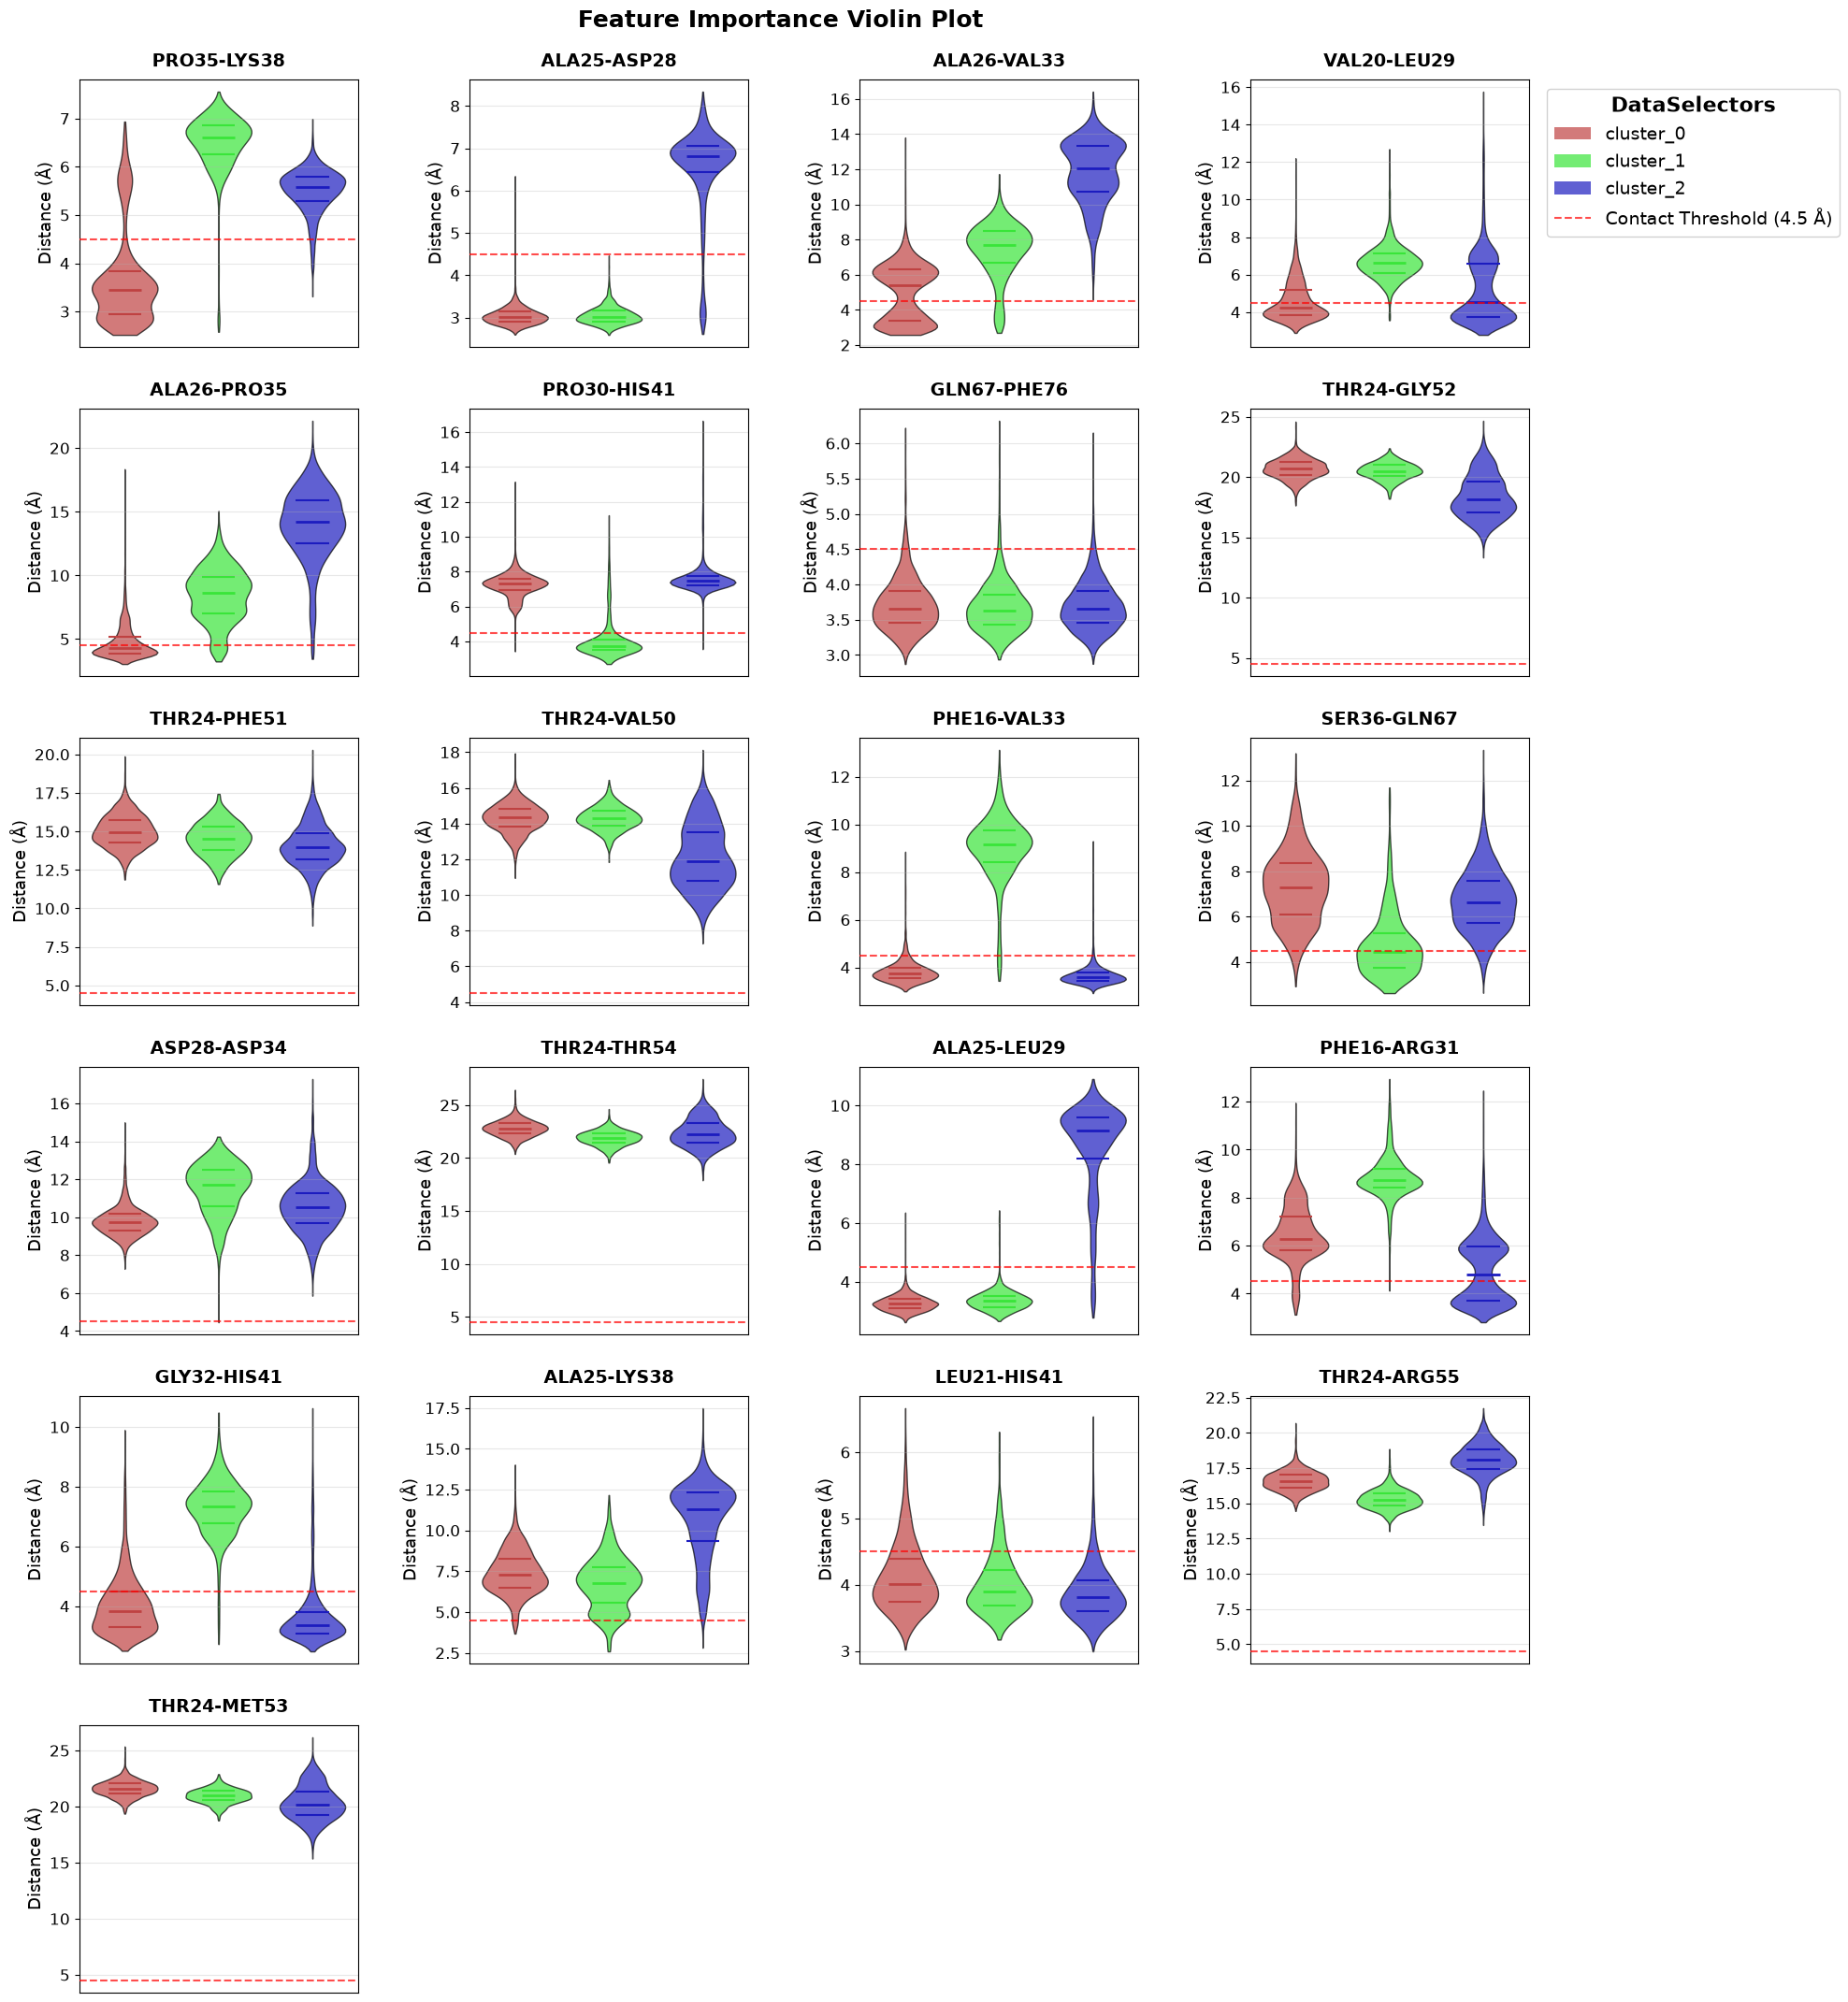

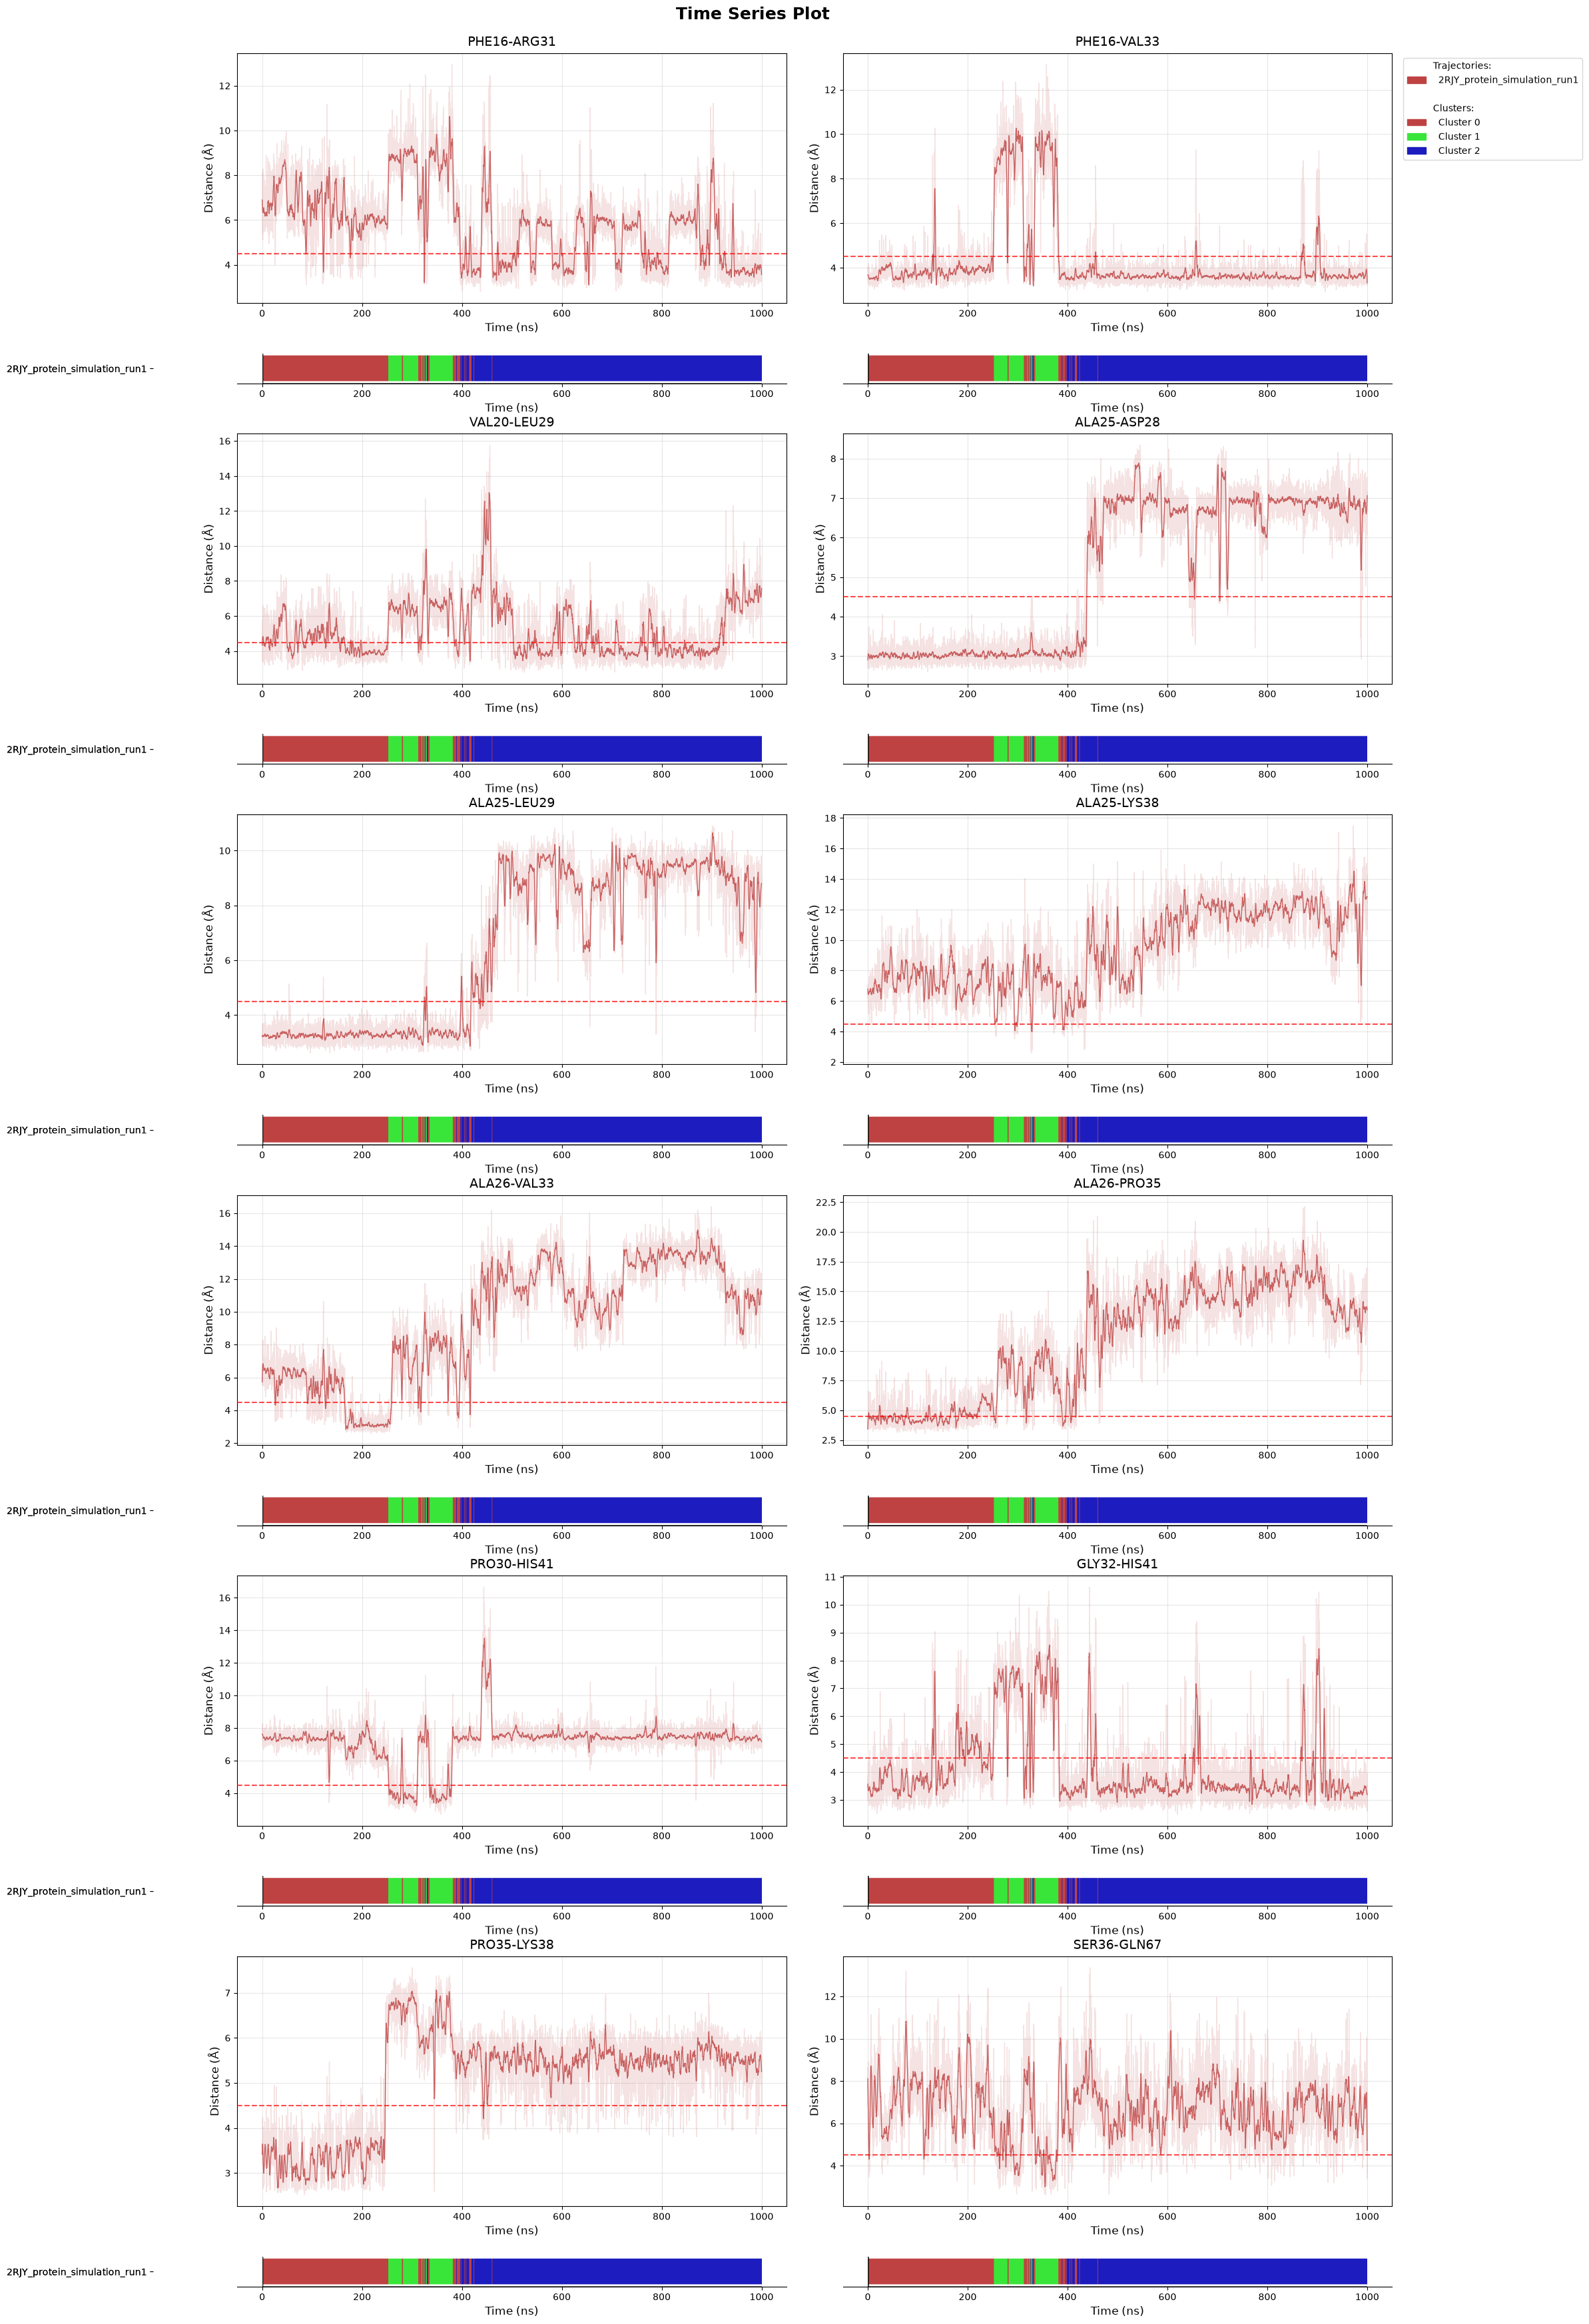

In [2]:
pipeline = PipelineManager(use_memmap=True, chunk_size=1000, show_progress=False)

pipeline.trajectory.load_trajectories("../../data/2RJY/")
pipeline.trajectory.add_labels(
        traj_selection="all"
    )
pipeline.feature.add.distances()
pipeline.feature.add.contacts(cutoff=4.5)
pipeline.feature_selector.create("contacts_only")
pipeline.feature_selector.add.contacts("contacts_only", "all")
pipeline.feature_selector.select("contacts_only")
pipeline.decomposition.add.contact_kernel_pca(
    n_components=4,
    selection_name="contacts_only", 
    decomposition_name="ContactKernelPCA",
)
pipeline.clustering.add.dpa(
    "ContactKernelPCA", 
    Z=2.5,
    cluster_name="DPA_ContactKPC",
)
fig = pipeline.plots.clustering.membership(
    clustering_name="DPA_ContactKPC",
)
fig = pipeline.plots.landscape(
    decomposition_name="ContactKernelPCA",
    dimensions=[0, 1, 2, 3],
    clustering_name="DPA_ContactKPC",
)
pipeline.data_selector.create_from_clusters(
    group_name="cluster",
    clustering_name="DPA_ContactKPC"
)

# Create one-vs-all comparison
pipeline.comparison.create_comparison(
    name="cluster_comparison",
    mode="one_vs_rest",
    feature_selector="contacts_only",
    data_selector_groups="cluster"
)
pipeline.feature_importance.add.decision_tree(
    comparison_name="cluster_comparison",
    analysis_name="feature_importance",
)
fig = pipeline.plots.feature_importance.decision_trees(
    feature_importance_name="feature_importance",
)
fig = pipeline.plots.feature_importance.violins(
    feature_importance_name="feature_importance",
)
fig = pipeline.plots.feature_importance.time_series(
    feature_importance_name="feature_importance",
    membership_per_feature=True,
    clustering_name="DPA_ContactKPC",
)
pipeline.structure_visualization.feature_importance.create_pdb_with_beta_factors(
    structure_viz_name="structure_viz",
    feature_importance_name="feature_importance",
)
pipeline.print_info()

In [3]:
log = pipeline.data.log
for entry in log["operations"].values():
    print(f"Operation {entry['global_seq']}:")
    for key, value in entry.items():
        if key == "global_seq":
            continue
        if key == "config":
            print(f"    {key}:")
            for config_key, config_value in value.items():
                print(f"        {config_key}: {config_value}")
        else:
            print(f"    {key}: {value}")


Operation 1:
    id: pipeline_init_1
    type: pipeline_init
    config:
        stride: 1
        concat: False
        selection: None
        use_memmap: True
        reuse_memmap_cache: False
        chunk_size: 1000
        dtype: <class 'numpy.float32'>
        cache_dir: /home/maeve/Dokumente/Work/mdxplain/Repository/mdxplain/spec/tests/cache/cache_8e39964c2fc9491e9a0ab1767ce21dcb_20260827_145502
        max_memory_gb: 6.0
    depends_on: []
Operation 2:
    id: TrajectoryManager.load_trajectories_1
    type: TrajectoryManager.load_trajectories
    config:
        data_input: ../../data/2RJY/
        concat: None
        stride: 1
        selection: None
        force: False
    depends_on: []
Operation 3:
    id: TrajectoryManager.add_labels_1
    type: TrajectoryManager.add_labels
    config:
        traj_selection: all
        fragment_definition: None
        fragment_type: None
        fragment_molecule_name: None
        consensus: False
        aa_short: False
        try

In [14]:
spec_manager = SpecManager(project="2RJY", trajectory_path="../../data/2RJY/")
spec_manager.read_from_pipeline(pipeline)
spec_manager.write_json("spec.json")

In [14]:
example_spec = SpecManager(project="2RJY_manual", trajectory_path="../../data/2RJY/")
example_spec.add_project_metadata(use_memmap=True, chunk_size=1000)
example_spec.add_trajectory_metadata(trajectory_names=["Placeholder"], res_label_data={}) # Hier müsste man sowas wie selection=all, damit die Konvention nicht gebrochen wird zu mdxplain Aufruf: add_labels
example_spec.add_feature_metadata(name="distances", feature_type="distances", computation_params={})
# Es fehlen die automatischen params:
#        "excluded_neighbors": 1,
#        "scheme": "closest-heavy"
example_spec.add_feature_metadata(name="contacts", feature_type="contacts", computation_params={"cutoff": 4.5}) # Sollte das spezifisch auf die Feature types und deren param angepasst werden?
# hier fehlen auch die default params
example_spec.add_feature_selection_metadata(name="contacts_only", selections={"contacts": [{"selection": "all"}]}) # das bricht auch mit selection="all" und da fehlt, dass es das contact feature ist
example_spec.add_decomposition_metadata(name="ContactKernelPCA", decomposition_type="contact_kernel_pca", hyperparameters={"n_components": 4, "selection_name": "contacts_only"}) # Sollte das auch nach type sein?
# manchmal comutation_params, manchmal hyperparameters?
# hier fehlen params
example_spec.add_clustering_metadata(name="DPA_ContactKPC", cluster_type="dpa", hyperparameters={"Z": 2.5, "decomposition_name": "ContactKernelPCA"})
# hier fehlen auch die default params
example_spec.add_data_selector_metadata(name="cluster", selection_criteria={"clustering_name": "DPA_ContactKPC"}) # Unklar was hier rein muss
# keine group Funktion --> es fehlt so ziemlich alles
example_spec.add_comparison_metadata(name="cluster_comparison", mode="one_vs_rest", feature_selector="contacts_only", sub_comparisons=[{"cluster": {"group_name": "cluster"}}, {"placeholder": {"group_name": "placeholder"}}]) # Umständlich mit den manuellen sub_comparisons, fehleranfällig
# Keine Gruppen, warum mehrere sub comparsions verpflichtend? es kann doch auch nur eine comp sien?
example_spec.add_feature_importance_metadata(name="feature_importance", analyzer_type="decision_tree", comparison_name="cluster_comparison", feature_selector="contacts_only", hyperparameters={})

example_spec.add_structure_visualization_metadata(name="structure_viz", source_type="feature", feature_importance_name="feature_importance")
# Wäre bei dieser Komplexität schon ein AddService sinnvoll?
example_spec.write_json("spec_manual.json")